In [5]:
import functools
import os
import random
from concurrent import futures
from typing import Callable

import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd

from synthetic.model import Layer, RandomValue, do_synthetic, trim, normalise, rmse, r2, resample_y

In [6]:
DATA_DIR = "../data"
datafile = functools.partial(os.path.join, DATA_DIR)
mean_rf_t, mean_rf_y = np.load(datafile("mean_rf.npy"))
random.seed(100)
iterations = 5000
top_n = int(0.05 * iterations)
colours = ("red", "green", "cyan", "orange")
ref_mean = trim(0, 10, mean_rf_t, mean_rf_y)
depth_lim = 60e3


def prf(evt_id: str):
    return np.load(datafile(f"prfs/{evt_id}.npy"))

In [7]:
# def run_params(filename: str, layers: [Layer]):
#     fields = [
#         "rmse", "r^2",
#         *[f"{t}{i + 1}" for i in range(len(layers)) for t in ("thick", "depth", "v_p", "v_s", "rho")]
#     ]
#     with open(datafile(f"rand_models/{filename}.csv"), "w") as file:
#         writer = csv.DictWriter(file, dialect='unix', fieldnames=fields)
#         writer.writeheader()
#         for i in range(iterations):
#             ll = [l.resolve() for l in layers]
#             xx, yy, model = do_synthetic(ll)
#             xx, yy = trim(0, 10, *normalise(xx, yy))
#             y1, y2 = resample_y(xx, yy, mx, my)
#             thk = {f"thick{i + 1}": v.thickness for i, v in enumerate(ll)}
#             v_s = {f"v_s{i + 1}": v.v_s for i, v in enumerate(ll)}
#             v_p = {f"v_p{i + 1}": v.v_p for i, v in enumerate(ll)}
#             rho = {f"rho{i + 1}": v.rho for i, v in enumerate(ll)}
#             dpt = {f"depth{i}": sum(l.thickness for l in ll[:i]) for i in range(1, len(ll))}
#             writer.writerow(
#                 {"rmse": rmse(y1, y2), "r^2": r2(y1, y2)} | thk | dpt | v_s | v_p | rho
#             )
#     print(f"{filename} done")

In [8]:
def depths_to_thickness(depths) -> [float]:
    last_depth = 0
    thicknesses = [0] * len(depths)
    for i, d in enumerate(sorted(depths)):
        thicknesses[i] = d - last_depth
        last_depth = d
    return thicknesses

## Three layer

In [9]:
def model_3a() -> [Layer]:
    depths = [9500, 12500, 35000]
    dd = [
        depths[0] + RandomValue(-2500, 2500, 50)(),
        depths[1] + RandomValue(-5000, 5000, 50)(),
        depths[2] + RandomValue(-10000, 10000, 50)(),
    ]
    tt = depths_to_thickness(dd)
    return [
        Layer(thickness=tt[0], v_p=3800, v_s=1850, rho=2304),
        Layer(thickness=tt[1], v_p=4500, v_s=2800, rho=2570),
        Layer(thickness=tt[2], v_p=6220, v_s=3750, rho=2863),
        Layer(thickness=0, v_p=7670, v_s=4330, rho=3446),
    ]


def model_3b() -> [Layer]:
    dd = [
        10000 + RandomValue(-5000, 5000, 50)(),
        22000 + RandomValue(-5000, 5000, 50)(),
        40000 + RandomValue(-10000, 15000, 50)(),
    ]
    tt = depths_to_thickness(dd)
    return [
        Layer(thickness=tt[0], v_p=3800, v_s=1850, rho=2304),
        Layer(thickness=tt[1], v_p=4500, v_s=2800, rho=2570),
        Layer(thickness=tt[2], v_p=6220, v_s=3750, rho=2863),
        Layer(thickness=0, v_p=7670, v_s=4330, rho=3446),
    ]


def model_3c() -> [Layer]:
    dd = [
        10000 + RandomValue(-5000, 5000, 50)(),
        22000 + RandomValue(-5000, 5000, 50)(),
        40000 + RandomValue(-10000, 15000, 50)(),
    ]
    v_s = [
        1850 + RandomValue(-500, 500, 10)(),
        2800 + RandomValue(-500, 500, 10)(),
        3750 + RandomValue(-500, 500, 10)(),
        4330 + RandomValue(-500, 500, 10)(),
    ]
    v_p = [
        3800 + RandomValue(-500, 500, 10)(),
        4500 + RandomValue(-500, 500, 10)(),
        6220 + RandomValue(-500, 500, 10)(),
        7670 + RandomValue(-500, 500, 10)(),
    ]
    rho = [
        2300 + RandomValue(-500, 500, 10)(),
        2570 + RandomValue(-500, 500, 10)(),
        2863 + RandomValue(-500, 500, 10)(),
        3446 + RandomValue(-500, 500, 10)(),
    ]
    tt = depths_to_thickness(dd)
    return [
        Layer(thickness=tt[0], v_s=v_s[0], v_p=v_p[0], rho=rho[0]),
        Layer(thickness=tt[1], v_s=v_s[1], v_p=v_p[1], rho=rho[1]),
        Layer(thickness=tt[2], v_s=v_s[2], v_p=v_p[2], rho=rho[2]),
        Layer(thickness=0, v_s=v_s[3], v_p=v_p[3], rho=rho[3]),
    ]


def model_2a() -> [Layer]:
    dd = [
        10000 + RandomValue(-5000, 5000, 50)(),
        25000 + RandomValue(-5000, 5000, 50)(),
    ]
    tt = depths_to_thickness(dd)
    return [
        Layer(thickness=tt[0], v_p=3800, v_s=1850, rho=2304),
        Layer(thickness=tt[1], v_p=4500, v_s=2800, rho=2570),
        Layer(thickness=0, v_p=7670, v_s=4330, rho=3446),
    ]


def model_2b() -> [Layer]:
    dd = [
        10000 + RandomValue(-5000, 5000, 50)(),
        30000 + RandomValue(-15000, 15000, 50)(),
    ]
    v_s = [
        1850 + RandomValue(-500, 500, 10)(),
        2800 + RandomValue(-500, 500, 10)(),
        3750 + RandomValue(-1000, 1000, 10)(),
    ]
    v_p = [
        3800 + RandomValue(-500, 500, 10)(),
        4500 + RandomValue(-500, 500, 10)(),
        6220 + RandomValue(-1000, 1000, 10)(),
    ]
    rho = [
        2300 + RandomValue(-500, 500, 10)(),
        2570 + RandomValue(-500, 500, 10)(),
        2863 + RandomValue(-1000, 1000, 10)(),
    ]
    tt = depths_to_thickness(dd)
    return [
        Layer(thickness=tt[0], v_s=v_s[0], v_p=v_p[0], rho=rho[0]),
        Layer(thickness=tt[1], v_s=v_s[1], v_p=v_p[1], rho=rho[1]),
        Layer(thickness=0, v_s=v_s[2], v_p=v_p[2], rho=rho[2]),
    ]


def model_run(fn: Callable, iters: int, ref_model) -> pd.DataFrame:
    name = getattr(fn, '__name__', 'Unknown')
    rows = []
    for i in range(iters):
        ll = fn()
        xx, yy, model = do_synthetic(ll)
        xx, yy = trim(0, 10, *normalise(xx, yy))
        y1, y2 = resample_y(xx, yy, *ref_model)
        thk = {f"thick{i + 1}": v.thickness for i, v in enumerate(ll)}
        v_s = {f"v_s{i + 1}": v.v_s for i, v in enumerate(ll)}
        v_p = {f"v_p{i + 1}": v.v_p for i, v in enumerate(ll)}
        rho = {f"rho{i + 1}": v.rho for i, v in enumerate(ll)}
        dpt = {f"depth{i}": sum(l.thickness for l in ll[:i]) for i in range(1, len(ll))}
        rows.append(
            {"rmse": rmse(y1, y2), "r^2": r2(y1, y2)} | thk | dpt | v_s | v_p | rho
        )
        if i % 1000 == 0:
            print(f"{name}: {i}/{iters}", flush=True)
    return pd.DataFrame(rows)

In [10]:
ex = futures.ProcessPoolExecutor(max_workers=8)
res_3a = ex.submit(model_run, model_3a, iterations, ref_mean)
res_3b = ex.submit(model_run, model_3b, iterations, ref_mean)
res_2a = ex.submit(model_run, model_2a, iterations, ref_mean)
res_3c = ex.submit(model_run, model_3c, iterations, ref_mean)
res_2b = ex.submit(model_run, model_2b, iterations, ref_mean)
ex.shutdown()

model_3b: 0/5000model_3a: 0/5000

model_3c: 0/5000
model_2a: 0/5000
model_2b: 0/5000
model_2b: 1000/5000
model_3b: 1000/5000
model_3a: 1000/5000
model_2a: 1000/5000
model_3c: 1000/5000
model_3a: 2000/5000
model_3b: 2000/5000
model_2b: 2000/5000
model_2a: 2000/5000
model_3c: 2000/5000
model_3b: 3000/5000
model_2b: 3000/5000
model_3a: 3000/5000
model_3c: 3000/5000
model_2a: 3000/5000
model_3b: 4000/5000
model_2b: 4000/5000
model_3a: 4000/5000
model_2a: 4000/5000
model_3c: 4000/5000


In [11]:
l2a_df = res_2a.result()
l2b_df = res_2b.result()
l3a_df = res_3a.result()
l3b_df = res_3b.result()
l3c_df = res_3c.result()

In [12]:
# l3a_df = l3a_df.sort_values("rmse", ascending=True)
# l3b_df = l3b_df.sort_values("rmse", ascending=True)
# l2a_df = l2a_df.sort_values("rmse", ascending=True)
l2a_df = l2a_df.sort_values("r^2", ascending=False)
l2b_df = l2b_df.sort_values("r^2", ascending=False)
l3a_df = l3a_df.sort_values("r^2", ascending=False)
l3b_df = l3b_df.sort_values("r^2", ascending=False)
l3c_df = l3c_df.sort_values("r^2", ascending=False)
l2a_df

,rmse,r^2,thick1,thick2,thick3,depth1,depth2,v_s1,v_s2,v_s3,v_p1,v_p2,v_p3,rho1,rho2,rho3
3169,0.077460,5.511413e-01,8750.0,16500.0,0,8750.0,25250.0,1850,2800,4330,3800,4500,7670,2304,2570,3446
365,0.077585,5.498507e-01,8850.0,16500.0,0,8850.0,25350.0,1850,2800,4330,3800,4500,7670,2304,2570,3446
3694,0.077699,5.494954e-01,8800.0,16850.0,0,8800.0,25650.0,1850,2800,4330,3800,4500,7670,2304,2570,3446
3152,0.077887,5.474453e-01,8800.0,16100.0,0,8800.0,24900.0,1850,2800,4330,3800,4500,7670,2304,2570,3446
1309,0.078258,5.457277e-01,8700.0,16700.0,0,8700.0,25400.0,1850,2800,4330,3800,4500,7670,2304,2570,3446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1484,0.266228,1.742579e-07,5250.0,17750.0,0,5250.0,23000.0,1850,2800,4330,3800,4500,7670,2304,2570,3446
4897,0.217700,2.905700e-08,14550.0,12400.0,0,14550.0,26950.0,1850,2800,4330,3800,4500,7670,2304,2570,3446
3489,0.217702,2.575322e-08,14650.0,12100.0,0,14650.0,26750.0,1850,2800,4330,3800,4500,7670,2304,2570,3446
3251,0.220822,2.506525e-09,12700.0,13650.0,0,12700.0,26350.0,1850,2800,4330,3800,4500,7670,2304,2570,3446


In [20]:
def km_fmt(x, pos):  # your custom formatter function: divide by 100.0
    return f"{x / 1000:n}"


def plot_hist(df: pd.DataFrame, hist_ax, head, n_layers):
    df = df.head(head)
    for i in range(n_layers - 1):
        hist_ax.hist(df[f"depth{i + 1}"], bins=10, alpha=0.5, orientation="horizontal")


def plot_layers(df: pd.DataFrame, layers_ax, n_layers):
    best = df.iloc[0]
    print(best["rmse"])
    dd = [0] + [best[f"depth{i + 1}"] for i in range(n_layers - 1)] + [depth_lim]
    v_s = [best[f"v_s{i + 1}"] for i in range(n_layers)]
    v_p = [best[f"v_p{i + 1}"] for i in range(n_layers)]
    rho = [best[f"rho{i + 1}"] for i in range(n_layers)]
    layers_ax.stairs(v_s, dd, orientation="horizontal", label="$V_s$")
    layers_ax.stairs(v_p, dd, orientation="horizontal", label="$V_p$")
    layers_ax.stairs(rho, dd, orientation="horizontal", label=r"$\rho$")
    layers_ax.legend(loc="best")


def plot_rf(df: pd.DataFrame, rf_ax, n_layers, ref_model, prf_name):
    layers = [Layer(
        thickness=df.head(1)[f"thick{i + 1}"],
        rho=df.head(1)[f"rho{i + 1}"],
        v_p=df.head(1)[f"v_p{i + 1}"],
        v_s=df.head(1)[f"v_s{i + 1}"],
    ) for i in range(n_layers)]
    xx, yy, model = do_synthetic(layers)
    xx, yy = normalise(*trim(0, 10, xx, yy))
    rf_ax.plot(xx, yy, label="Synthetic")
    rf_ax.plot(*ref_model, label=prf_name)
    rf_ax.legend(loc=1)


def plot_solution(name: str, df: pd.DataFrame, ref_model, depth_lim=60e3, hist=True, prf_name="Mean PRF") -> plt.Figure:
    n_layers = len(list(filter(lambda x: x.startswith("thick"), df.columns)))
    # with plt.style.context("dark_background"):
    fig = plt.figure(figsize=(6, 8), dpi=100, constrained_layout=True)
    fig.suptitle(f"{name}\n$R^2={df.iloc[0]['r^2']:.3f};\; RMSE={df.iloc[0]['rmse']:.3f}$")
    gs = plt.GridSpec(ncols=2, nrows=2, width_ratios=[3, 1], height_ratios=[3, 1], figure=fig)
    if hist:
        layer_ax = fig.add_subplot(gs[0, 0])
        hist_ax = fig.add_subplot(gs[0, 1], sharey=layer_ax)
        hist_ax.set_xticks([])
        hist_ax.yaxis.set_tick_params(labelleft=False)
        plot_hist(df, hist_ax, top_n, n_layers)
    else:
        layer_ax = fig.add_subplot(gs[0, :])
    layer_ax.yaxis.set_major_formatter(tkr.FuncFormatter(km_fmt))
    layer_ax.set_ylabel("Depth (km)")
    layer_ax.set_xlabel(r"$V\; (m.s^{-1}) $ — $ \rho\; (kg.m^{-3})$")
    layer_ax.grid(linewidth=.5)
    rf_ax = fig.add_subplot(gs[1, :])
    rf_ax.set_ylim((-1, 1))
    rf_ax.set_yticks([])
    rf_ax.set_xlabel("time (s)")
    layer_ax.set_ylim((depth_lim, 0))
    plot_layers(df, layer_ax, n_layers)
    plot_rf(df, rf_ax, n_layers, ref_model, prf_name)
    return fig

In [21]:
fig2 = plot_solution("Three layer solution", l3b_df, ref_mean)
fig2.savefig(datafile("figures/solution_l3b.png"))
pd.set_option('display.max_columns', None)
l2a_df.head(1)

0.08362360869189996


,rmse,r^2,thick1,thick2,thick3,depth1,depth2,v_s1,v_s2,v_s3,v_p1,v_p2,v_p3,rho1,rho2,rho3
3169,0.07746,0.551141,8750.0,16500.0,0,8750.0,25250.0,1850,2800,4330,3800,4500,7670,2304,2570,3446


In [22]:
fig3 = plot_solution("Two layer solution", l2a_df, ref_mean)
fig3.savefig(datafile("figures/solution_l2a.png"))

0.07745984798029398


0.08547865820721245


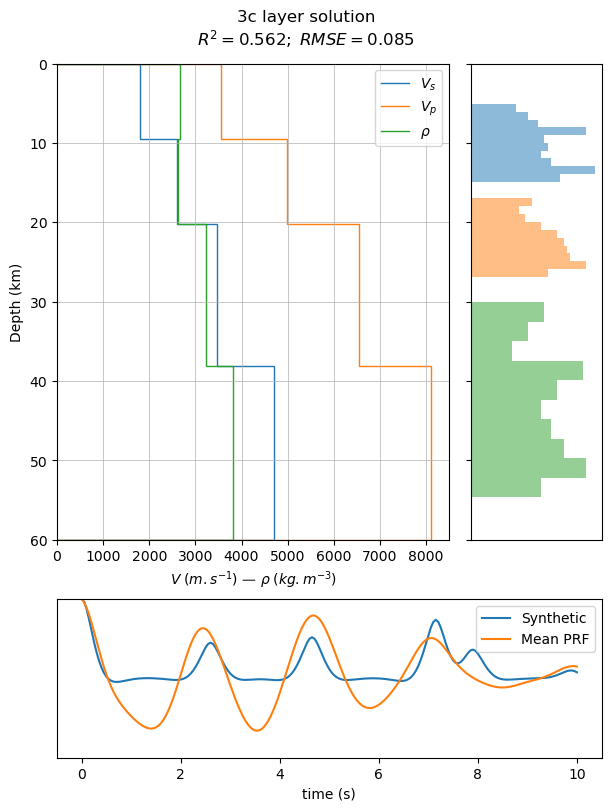

In [23]:
fig4 = plot_solution("3c layer solution", l3c_df, ref_mean)
fig4

## Shi et al Models

In [19]:
# def shi_et_al_4a():
#     return [
#         Layer(thickness=2000, v_p=5000, v_s=3000, rho=2500),
#         Layer(thickness=8000, v_p=3800, v_s=1850, rho=2304),
#         Layer(thickness=12000, v_p=4500, v_s=2800, rho=2570),
#         Layer(thickness=24000, v_p=6220, v_s=3750, rho=2863),
#         Layer(thickness=0, v_p=7670, v_s=4330, rho=3446),
#     ]
def shi_et_al_4a():
    return [
        Layer(thickness=2000, v_p=5000, v_s=3000, rho=2500),
        Layer(thickness=8000, v_p=3800, v_s=1850, rho=2304),
        Layer(thickness=15000, v_p=4500, v_s=2800, rho=2570),
        Layer(thickness=27000, v_p=6220, v_s=3750, rho=2863),
        Layer(thickness=0, v_p=7670, v_s=4330, rho=3446),
    ]


# def shi_et_al_4b():
#     return [
#         Layer(thickness=1200, v_p=2800, v_s=1500, rho=2100),
#         Layer(thickness=10300, v_p=4400, v_s=2450, rho=2304),
#         Layer(thickness=13000, v_p=7100, v_s=3800, rho=2570),
#         Layer(thickness=24000, v_p=6220, v_s=3750, rho=2863),
#         Layer(thickness=0, v_p=7670, v_s=4330, rho=3446),
#     ]

def shi_et_al_4b():
    return [
        Layer(thickness=1000, v_p=2800, v_s=1500, rho=2100),
        Layer(thickness=8000, v_p=3800, v_s=1850, rho=2304),
        Layer(thickness=15000, v_p=4500, v_s=2800, rho=2570),
        Layer(thickness=27000, v_p=6220, v_s=3750, rho=2863),
        Layer(thickness=0, v_p=7670, v_s=4330, rho=3446),
    ]


S1022a = trim(0, 10, *normalise(*prf("S1222a")))

s4a = model_run(shi_et_al_4a, 1, S1022a)
s4b = model_run(shi_et_al_4b, 1, S1022a)
fig_s4a = plot_solution("Shi et al 2023 (fast)", s4a, S1022a, hist=False, prf_name="S1222a")
fig_s4a.savefig(datafile("figures/solution_shi_fast.png"))
fig_s4b = plot_solution("Shi et al 2023 (slow)", s4b, S1022a, hist=False, prf_name="S1222a")
fig_s4b.savefig(datafile("figures/solution_shi_slow.png"))

shi_et_al_4a: 0/1
shi_et_al_4b: 0/1
0.12276181435045652
0.0714304433045701
